# Approximate multi-controlled X gate

**Download Notebook** - {nb-download}`cnx_approx.ipynb`

## Empirical Validation

The $C^nX$ gate applies an X gate to a target qubit only when all n control qubits are in the $|1\rangle$ state.

Exact implementations require $O(n)$ $T$ gates, whereas the approximate $C^nX$ gate requires only $O(log(1/\epsilon))$ $T$ gates for an implementation within an error $\epsilon$ .

This algorithm for the approximate multi-controlled X gate originates from the paper [arXiv:2510.07223](https://arxiv.org/abs/2510.07223) "Multi-qubit Toffoli with exponentially fewer T gates".

In [ ]:
from math import ceil, log2
from guppylang import guppy
from guppylang.std.builtins import array, comptime, output
from guppylang.std.quantum import qubit, x, measure, discard_array
from guppylang.std.qsystem.random import RNG
from guppylang.std.qsystem.utils import get_current_shot
from guppyalgos.primitives.gate_decompositions.cnx.cnx_approx import cnx_approx
from guppyalgos.utils import qarray

We define the following parameters:

- **N_CTRL**: Number of control qubits
- **EPSILON**: Error bound
- **SEED**: Seed for random number generation
- **N_SHOTS**: Number of simulation runs to estimate error rate

In [5]:
N_CTRL = 10
EPSILON = 0.1
SEED = 1
N_SHOTS = 1000

# Generate the approximate CnX gate with and error EPSILON and N_CTRL control qubits
cnx_approx_fn = cnx_approx(N_CTRL, EPSILON)

# Number of controls for the exact CnX gate
k = min(ceil(log2(1 / EPSILON)) + 2, N_CTRL)

print(f"Number of controls: {N_CTRL}")
print(f"Target epsilon: {EPSILON}")
print(f"Number of shots: {N_SHOTS}")

Number of controls: 10
Target epsilon: 0.1
Number of shots: 1000


To verify the approximate $C^nX$ gate implementation, we set up a test where some control qubits are initialized in $\lvert 0 \rangle$.
Since not all controls are $|1\rangle$, the target should remain $|0\rangle$ after applying $C^nX$. We expect the error rate to be at most $\epsilon$.

In [ ]:
@guppy
def test_cnx_approx() -> None:
    # Initialize controls
    controls = qarray(N_CTRL)
    for i in range(comptime(N_CTRL - 1)):
        x(controls[i])

    # Initialize target to |0⟩
    target = qubit()

    # Create RNG with shot-dependent seed
    rng = RNG(SEED + get_current_shot())

    # Apply approximate cnx gate
    cnx_approx_fn(controls, target, rng)

    # Measure target
    target_result = measure(target).read()
    output("target_result", target_result)

    # Cleanup
    rng.discard()
    discard_array(controls)

We run the circuit N_SHOTS times to statistically estimate the error rate of the approximation.
A shot is successful if the target is measured as $|0\rangle$.

In [7]:
n_ancillas = (k - 2) // 2 + (k - 2) % 2 if k > 2 else 0
n_qubits = N_CTRL + 1 + n_ancillas

results = test_cnx_approx.emulator(n_qubits=n_qubits).with_shots(N_SHOTS).run()

shots_data = results.collated_shots()
successes = sum(1 for shot in shots_data if not shot["target_result"][0])
success_rate = successes / N_SHOTS
error_rate = 1 - success_rate

print(f"\n=== Results ===")
print(f"Epsilon: {EPSILON}")
print(f"Successes: {successes}/{N_SHOTS}")
print(f"Success rate: {success_rate:.4f}")
print(f"Error rate: {error_rate:.4f}")


=== Results ===
Epsilon: 0.1
Successes: 994/1000
Success rate: 0.9940
Error rate: 0.0060


## Resource Estimation

The algorithm guarantees that the approximate $C^nX$ is implemented to within error $\varepsilon$ in the diamond distance.
To do this approximation, the algorithm requires an exact $C^kX$ gate where $k$ is given by:
$$k = \lceil \log_2(1/\varepsilon) \rceil + 2.$$

The key advantage is that $k$ grows logarithmically with $1/\varepsilon$ and is independent of $n$, the number of controls in the $C^nX$ gate. This means the $T$-count is $O(\log(1/\varepsilon))$ instead of $O(n)$.

The graph below shows the $k$ value with respect to $\varepsilon$.
For example, for $\varepsilon = 0.01$, we get $k = 9$. This means that a $C^nX$ gate ($n$ controls) can be approximated with the same number of $T$ gates as implementing an exact $C^{9}X$ gate (9 controls).


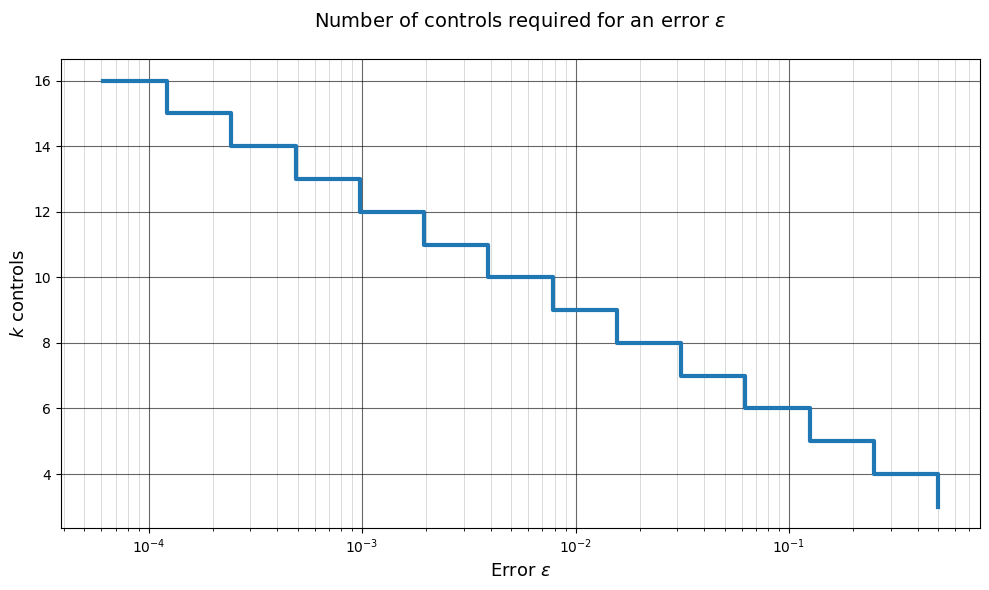

In [18]:
import matplotlib.pyplot as plt
import numpy as np

epsilon_values = np.array(sorted([2**(-k) for k in range(1, 15)]))
k_values = np.array([ceil(log2(1 / eps)) + 2 for eps in epsilon_values])

plt.figure(figsize=(10, 6))
plt.step(epsilon_values, k_values, where='post', linewidth=3)
plt.xscale('log')
plt.xlabel('Error $\\varepsilon$', fontsize=13)
plt.ylabel('$k$ controls', fontsize=13)
plt.title('Number of controls required for an error $\\varepsilon$\n', fontsize=14)
plt.grid(True, which='major', alpha=0.6, linewidth=0.8, color="black")
plt.grid(True, which='minor', alpha=0.2, linewidth=0.5, color="black")
plt.tight_layout()
plt.show()